# Implementacion del analisis parametrico del modelo de FitzHugh-Nagumo

Codigo de ejemplo en python para implementar el modelo FHN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

from matplotlib.ticker import FuncFormatter

## Grafica de Nullclines

### Experimento 1

Variacion de variable $B = [-1:0.2:1]$

In [2]:
# Definir las constantes globales

mm = np.arange(-1,1,0.2)

# a  = -1.5
# b  = -0.3
# c1 = 50
# c2 = 10
# d  = 2
# e  = 0.066
# A  = 0.035
# B  = -0.033
# k  = 1
# I  = 0.02

a = -0.5
b = 0
c1 = 1
c2 = 1
d = 1
e = 1/100
A = 1
B = 0
k = 1
I = 0.5



# Definir las funciones
def rhsV(w, v, a, b, c1, c2, d, e, A, B, k):
    return k*c1*(v - B)*(((v-B)/A)-a)*(1-((v-B)/A))-k*c2*w    # parameterized function

def rhsW(w, v, a, b, c1, c2, d, e, A, B, k):
    return k*e*(((v-B)/A)-d*w-b)     # parameterized function


In [3]:
mm

array([-1.00000000e+00, -8.00000000e-01, -6.00000000e-01, -4.00000000e-01,
       -2.00000000e-01, -2.22044605e-16,  2.00000000e-01,  4.00000000e-01,
        6.00000000e-01,  8.00000000e-01])

## Grafica de la trayectoria Nullclines

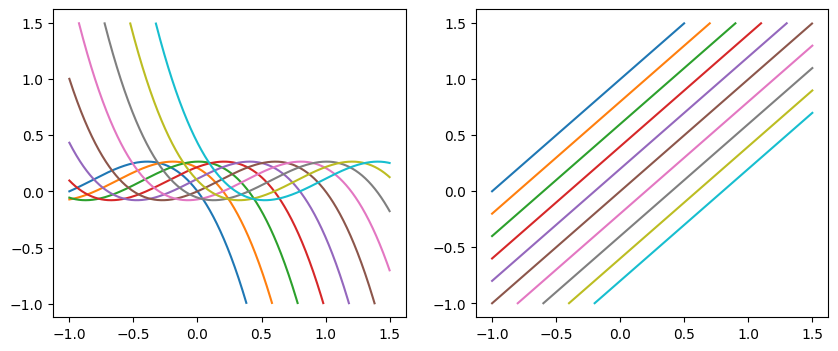

In [4]:
# l1 = -0.4
# l2 = 0.35

l1 = -1
l2 = 1.5

# Definir los rangos y listas de valores
vv = np.linspace(l1, l2, 1000)
nullv = []
nullw = []

nullvv = []
nullww = []

# Función auxiliar para encontrar un intervalo adecuado
def find_root(func, bracket, v):
    try:
        root = root_scalar(func, bracket=bracket, args=(v), method='brentq', xtol=1e-6)
        if root.converged:
            return root.root
        else:
            return np.nan
    except ValueError:
        return np.nan


# Evaluar los nullclines
for m in mm:
    B = m
    nullv = []
    nullw = []
    for v in vv:
        nullv.append(find_root(lambda w, v: rhsV(w, v, a, b, c1, c2, d, e, A, B, k), [l1, l2], v))
        nullw.append(find_root(lambda w, v: rhsW(w, v, a, b, c1, c2, d, e, A, B, k), [l1, l2], v))
    nullvv.append(nullv)
    nullww.append(nullw)
    

# Convertir listas a arrays para facilitar la manipulación
nullvv = np.array(nullvv)
nullww = np.array(nullww)

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(vv,nullvv.T)
plt.subplot(122)
plt.plot(vv,nullww.T)



In [5]:
# Constants for the method
dt = 0.01                  # delta time in ms
t = np.arange(0, 500, dt)   # time array in ms



# vectores para almacenar todas las senales
VVsol = []
WWsol = []


for m in mm:
    B = m
    Vsol = np.zeros(len(t))
    Wsol = np.zeros(len(t))
    Vsol[0] = np.array(-0.065)  # Valor inicial de la solucion
    Wsol[0] = np.array(0)  # Valor inicial de la solucion
    for i in range(0, len(t) - 1):

        # Euler method
        Vsol[i+1]= Vsol[i] + rhsV(Wsol[i], Vsol[i], a, b, c1, c2, d, e, A, B, k)*dt
        Wsol[i+1]= Wsol[i] + rhsW(Wsol[i], Vsol[i], a, b, c1, c2, d, e, A, B, k)*dt

    VVsol.append(Vsol)
    WWsol.append(Wsol)

VVsol = np.array(VVsol)
WWsol = np.array(WWsol)



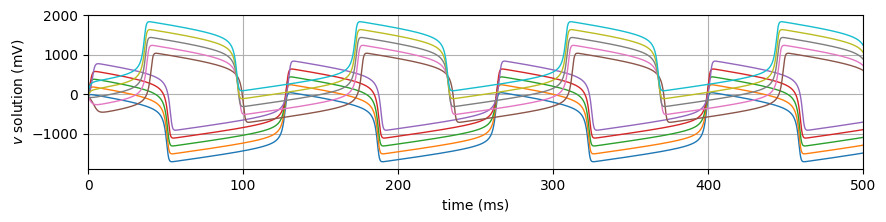

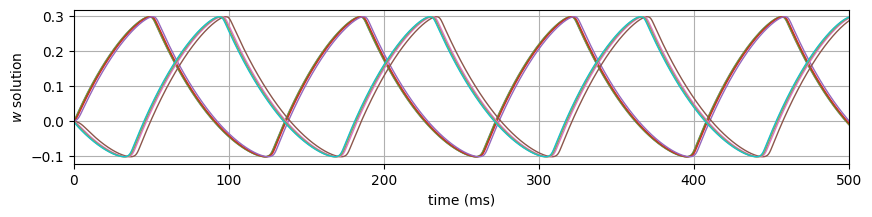

In [6]:
# Generar datos ficticios para T y Y
T = t
Y1 = VVsol.T
Y2 = WWsol.T

plt.figure(figsize=(10,2))
plt.plot(T, Y1*1000, linewidth = 1)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$v$ solution (mV)')
plt.xlim([0, 500])
#plt.ylim([-80, 60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/Bc_sweep_v.pdf", format="pdf", bbox_inches="tight")


# 
plt.figure(figsize=(10,2))
plt.plot(T, Y2, linewidth = 1)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$w$ solution')
plt.xlim([0, 500])
#plt.ylim([0.3, 0.8])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/Bc_sweep_w.pdf", format="pdf", bbox_inches="tight")


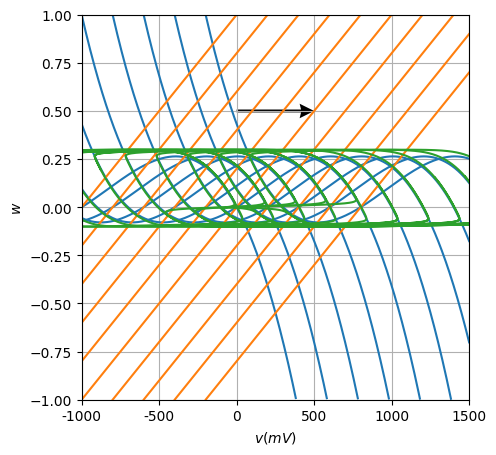

In [8]:
# Función para formatear los labels del eje x
def x_formatter(x, pos):
    return f'{x * 1000:.0f}'

# Calcular las diferencias entre puntos para las flechas
#dY = np.diff(Y[:,:], axis=0)

# posicion de los labels
p1 = 3940
p2 = 5000
p3 = 7150
p4 = 250

# Definir el rango de interés
ini = 0
fin = 20000

# Graficar los nullclines y la trayectoria
plt.figure(figsize=(5, 5))

# Nullclines
plt.plot(vv, nullvv.T, label='Nullcline $dv=0$', color='#1f77b4')
plt.plot(vv, nullww.T, label='Nullcline $dw=0$', color='#ff7f0e')

# Trayectoria
plt.plot(Y1[ini:fin, :], Y2[ini:fin, :], label='$v$-$w$ orbit', color='#2ca02c')

# Flechas para indicar la dirección del tiempo
skip = 50  # saltar puntos para no sobrecargar el gráfico con flechas
arrow_offset = 0.001  # desplazamiento de las flechas

plt.quiver(0, 0.5, 0.5, 0, angles='xy', scale_units='xy', scale=1, headwidth=5, headlength=5, color='black')


# Añadir etiquetas
#plt.text(Y[p1, 0], Y[p1, 1] - 70*arrow_offset, '$v$ increase\n $w$ stable', fontsize=10)
#plt.text(Y[p2, 0] + 3*arrow_offset, Y[p2, 1] , '$v$ max', fontsize=10)
#plt.text(Y[p3, 0], Y[p3, 1] + 20*arrow_offset, '$v$ decrease', fontsize=10)
#plt.text(Y[p4, 0]+ 2*arrow_offset, Y[p4, 1] + 2*arrow_offset, 'membrane\nrestore', fontsize=10)

# Personalizar los labels del eje x
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(x_formatter))

plt.xlabel('$v (mV)$')
plt.ylabel('$w$')
plt.axis([-1, 1.5, -1, 1])
#plt.legend()
#plt.title('Nullclines and Trajectory with Direction')
plt.grid(True)

#plt.show()

plt.savefig("output/Bc_sweep_null.pdf", format="pdf", bbox_inches="tight")